In [2]:
import pandas as pd
import numpy as np


In [3]:
data_files = {
    'sessions': ('session_time',),
    'trips': ('pickup_time', 'dropoff_time'),
    'riders': ('signup_date',),
    'drivers': ('signup_date', 'last_active'),
    'promotions': ('start_date', 'end_date')
}

dfs = {}
for name, date_cols in data_files.items():
    dfs[name] = pd.read_csv(f'../data/raw/{name}.csv', parse_dates=list(date_cols))

In [4]:
dfs['sessions'].head()

,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


In [5]:
dfs['sessions'].info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   session_id      50000 non-null  str  
 1   rider_id        50000 non-null  str  
 2   session_time    50000 non-null  str  
 3   time_on_app     50000 non-null  int64
 4   pages_visited   50000 non-null  int64
 5   converted       50000 non-null  int64
 6   city            50000 non-null  str  
 7   loyalty_status  50000 non-null  str  
dtypes: int64(3), str(5)
memory usage: 3.1 MB


In [6]:
dfs['sessions'].duplicated().sum()

np.int64(0)

In [7]:
dfs['sessions']['session_time'] = pd.to_datetime(dfs['sessions']['session_time'], utc=True, errors='coerce')

In [8]:
dfs['sessions']['session_time'].dtype

datetime64[us, UTC]

In [9]:
for col in dfs['sessions'].select_dtypes(include=['str', 'bool']).columns.tolist():
    print(dfs['sessions'][col].value_counts())
    print('-----------------------------')

session_id
S000000    1
S000001    1
S000002    1
S000003    1
S000004    1
          ..
S049995    1
S049996    1
S049997    1
S049998    1
S049999    1
Name: count, Length: 50000, dtype: int64
-----------------------------
rider_id
R03390    16
R08301    16
R00790    14
R08968    14
R03955    14
          ..
R05131     1
R02639     1
R07676     1
R05582     1
R00358     1
Name: count, Length: 9929, dtype: int64
-----------------------------
city
Cairo      16967
Nairobi    16598
Lagos      16435
Name: count, dtype: int64
-----------------------------
loyalty_status
Bronze      30298
Silver      12170
Gold         5197
Platinum     2335
Name: count, dtype: int64
-----------------------------


In [10]:
dfs['riders'].head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


In [11]:
dfs['riders'].info()
print('-----------------------------')
dfs['riders'].duplicated().sum()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           10000 non-null  str           
 1   signup_date       10000 non-null  datetime64[us]
 2   loyalty_status    10000 non-null  str           
 3   age               10000 non-null  float64       
 4   city              10000 non-null  str           
 5   avg_rating_given  10000 non-null  float64       
 6   churn_prob        10000 non-null  float64       
 7   referred_by       3053 non-null   str           
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 625.1 KB
-----------------------------


np.int64(0)

In [12]:
for col in dfs['riders'].select_dtypes(include=['str', 'bool']).columns.tolist():
    print(dfs['riders'][col].value_counts())
    print('-----------------------------')

user_id
R00000    1
R00001    1
R00002    1
R00003    1
R00004    1
         ..
R09995    1
R09996    1
R09997    1
R09998    1
R09999    1
Name: count, Length: 10000, dtype: int64
-----------------------------
loyalty_status
Bronze      6057
Silver      2425
Gold        1050
Platinum     468
Name: count, dtype: int64
-----------------------------
city
Cairo      3374
Nairobi    3330
Lagos      3296
Name: count, dtype: int64
-----------------------------
referred_by
R00002    46
R00001    33
R00033    32
R00030    24
R00021    22
          ..
R08187     1
R08370     1
R09768     1
R02155     1
R07447     1
Name: count, Length: 1660, dtype: int64
-----------------------------


In [13]:
dfs['riders']['referred_by'] = dfs['riders']['referred_by'].fillna('unknown')
dfs['riders'].head()



,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,unknown
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,unknown
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,unknown
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


In [14]:
dfs['trips'].head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


In [15]:
dfs['trips'].info()
print('-----------------------------')
dfs['trips'].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  str    
 1   user_id           200000 non-null  str    
 2   driver_id         200000 non-null  str    
 3   fare              200000 non-null  float64
 4   surge_multiplier  200000 non-null  float64
 5   tip               200000 non-null  float64
 6   payment_type      200000 non-null  str    
 7   pickup_time       200000 non-null  str    
 8   dropoff_time      200000 non-null  str    
 9   pickup_lat        200000 non-null  float64
 10  pickup_lng        200000 non-null  float64
 11  dropoff_lat       200000 non-null  float64
 12  dropoff_lng       200000 non-null  float64
 13  weather           200000 non-null  str    
 14  city              200000 non-null  str    
 15  loyalty_status    200000 non-null  str    
dtypes: float64(7), str(9)
memory us

np.int64(0)

In [16]:
dfs['trips'][['pickup_time', 'dropoff_time']] = dfs['trips'][['pickup_time', 'dropoff_time']].apply(
    pd.to_datetime, utc=True, errors='coerce'
)


In [17]:
dfs['trips'][['pickup_time', 'dropoff_time']].dtypes

pickup_time     datetime64[us, UTC]
dropoff_time    datetime64[us, UTC]
dtype: object

In [18]:
for col in dfs['trips'].select_dtypes(include=['str']).columns.tolist():
    print(dfs['trips'][col].value_counts())
    print('-----------------------------')

trip_id
T000000    1
T000001    1
T000002    1
T000003    1
T000004    1
          ..
T199995    1
T199996    1
T199997    1
T199998    1
T199999    1
Name: count, Length: 200000, dtype: int64
-----------------------------
user_id
R08152    42
R06728    39
R09210    38
R09908    37
R00739    37
          ..
R01782     7
R06836     7
R00197     6
R01184     6
R03232     6
Name: count, Length: 10000, dtype: int64
-----------------------------
driver_id
D03093    67
D01999    66
D01107    65
D02137    65
D02429    63
          ..
D01358    21
D04432    21
D01250    21
D04528    19
D00728    19
Name: count, Length: 5000, dtype: int64
-----------------------------
payment_type
Card            100326
Mobile Money     79661
Cash             20013
Name: count, dtype: int64
-----------------------------
weather
Sunny     120151
Rainy      39976
Cloudy     29874
Foggy       9999
Name: count, dtype: int64
-----------------------------
city
Cairo      67436
Nairobi    66705
Lagos      65859
Name: 

In [19]:
dfs['promotions'].head()

,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,city_scope,ab_test_groups,test_allocation,success_metric
0,P000,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-25,All,Nairobi,['All'],[1.0],Usage Frequency
1,P001,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-22,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
2,P002,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-16,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
3,P003,Loyalty Bonus,points,100.0,2025-04-26,2025-05-04,Gold+,Nairobi,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
4,P004,Loyalty Bonus,points,100.0,2025-04-26,2025-05-15,Gold+,Nairobi,['All'],[1.0],Usage Frequency


In [20]:
dfs['promotions'].info()
print('-----------------------------')
dfs['promotions'].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   promo_id         20 non-null     str           
 1   promo_name       20 non-null     str           
 2   promo_type       20 non-null     str           
 3   promo_value      20 non-null     float64       
 4   start_date       20 non-null     datetime64[us]
 5   end_date         20 non-null     datetime64[us]
 6   target_segment   20 non-null     str           
 7   city_scope       20 non-null     str           
 8   ab_test_groups   20 non-null     str           
 9   test_allocation  20 non-null     str           
 10  success_metric   20 non-null     str           
dtypes: datetime64[us](2), float64(1), str(8)
memory usage: 1.8 KB
-----------------------------


np.int64(0)

In [21]:
for col in dfs['promotions'].select_dtypes(include=['str']).columns.tolist():
    print(dfs['promotions'][col].value_counts())
    print('-----------------------------')

promo_id
P000    1
P001    1
P002    1
P003    1
P004    1
P005    1
P006    1
P007    1
P008    1
P009    1
P010    1
P011    1
P012    1
P013    1
P014    1
P015    1
P016    1
P017    1
P018    1
P019    1
Name: count, dtype: int64
-----------------------------
promo_name
First Ride Discount    8
Peak Hour Pass         5
Loyalty Bonus          5
Referral Special       2
Name: count, dtype: int64
-----------------------------
promo_type
discount        8
surge_waiver    5
points          5
credit          2
Name: count, dtype: int64
-----------------------------
target_segment
New       8
All       5
Gold+     5
Active    2
Name: count, dtype: int64
-----------------------------
city_scope
Nairobi       6
Lagos         5
All-Cities    5
Cairo         4
Name: count, dtype: int64
-----------------------------
ab_test_groups
['All']                                  10
['Control', 'Variant A', 'Variant B']    10
Name: count, dtype: int64
-----------------------------
test_allocation
[1.0

In [22]:
dfs['drivers'].head()

,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,2025-01-20,2025-01-06 18:23:09.312275,Cairo,0.679555
1,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786
2,D00002,4.5,Motorcycle,2024-05-02,2025-03-07 19:24:46.367672,Nairobi,0.593724
3,D00003,5.0,Motorcycle,2023-04-16,2025-03-26 19:16:24.253793,Nairobi,0.990000
4,D00004,4.4,Motorcycle,2023-05-28,2025-04-08 18:54:44.649615,Lagos,0.519773


In [23]:
dfs['drivers'].info()
print('-----------------------------')
dfs['drivers'].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   driver_id        5000 non-null   str           
 1   rating           5000 non-null   float64       
 2   vehicle_type     5000 non-null   str           
 3   signup_date      5000 non-null   datetime64[us]
 4   last_active      5000 non-null   datetime64[us]
 5   city             5000 non-null   str           
 6   acceptance_rate  5000 non-null   float64       
dtypes: datetime64[us](2), float64(2), str(3)
memory usage: 273.6 KB
-----------------------------


np.int64(0)

In [24]:
for col in dfs['drivers'].select_dtypes(include=['str']).columns.tolist():
    print(dfs['drivers'][col].value_counts())
    print('-----------------------------')

driver_id
D00000    1
D00001    1
D00002    1
D00003    1
D00004    1
         ..
D04995    1
D04996    1
D04997    1
D04998    1
D04999    1
Name: count, Length: 5000, dtype: int64
-----------------------------
vehicle_type
Sedan         2439
SUV           1742
Motorcycle     675
Luxury         144
Name: count, dtype: int64
-----------------------------
city
Lagos      1720
Nairobi    1709
Cairo      1571
Name: count, dtype: int64
-----------------------------


In [25]:
# Save processed dataframes to CSV files
for name, df in dfs.items():
    df.to_csv(f'../data/processed/{name}_cleaned.csv', index=False)
    print(f"Saved {name}: {df.shape}")


Saved sessions: (50000, 8)
Saved trips: (200000, 16)
Saved riders: (10000, 8)
Saved drivers: (5000, 7)
Saved promotions: (20, 11)


## Exploration  Data Analysis

In [27]:
# EDA FOR RIDERS DATASET
import matplotlib.pyplot as plt
import seaborn as sns

riders = pd.read_csv('../data/processed/riders_cleaned.csv', parse_dates=['signup_date'])
riders['churn'] = (riders['churn_prob'] >= 0.5).astype(int)

print(riders.shape)
riders.head()


(10000, 9)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,churn
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,0
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,unknown,1
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,unknown,1
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,unknown,0
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002,0


In [28]:
# Overall churn rate
churn_counts = riders['churn'].value_counts()
print(churn_counts)
print(f"\nChurn rate: {riders['churn'].mean():.2%}")

churn
0    8937
1    1063
Name: count, dtype: int64

Churn rate: 10.63%


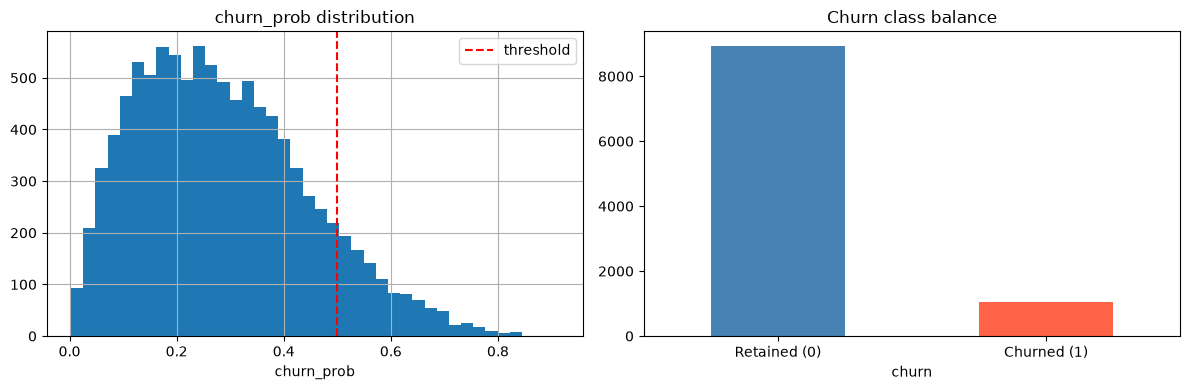

In [29]:
# Churn_probability distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

riders['churn_prob'].hist(bins=40, ax=axes[0])
axes[0].axvline(0.5, color='red', linestyle='--', label='threshold')
axes[0].set_title('churn_prob distribution')
axes[0].set_xlabel('churn_prob')
axes[0].legend()

riders['churn'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Churn class balance')
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
plt.tight_layout()
plt.show()

### Target variable

~10.6% churn rate (1,063 churners out of 10,000) — heavily imbalanced, which means you'll need to handle class imbalance (SMOTE) during modeling.

loyalty_status
Platinum    0.123932
Bronze      0.108470
Silver      0.101443
Gold        0.097143
Name: churn, dtype: float64


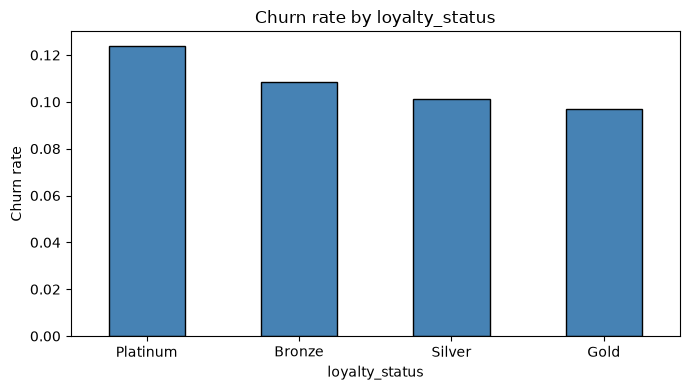

In [30]:
# Churn by loyalty_status
churn_loyalty = riders.groupby('loyalty_status')['churn'].mean().sort_values(ascending=False)
print(churn_loyalty)

churn_loyalty.plot(kind='bar', figsize=(7, 4), color='steelblue', edgecolor='black')
plt.title('Churn rate by loyalty_status')
plt.ylabel('Churn rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Insights
- It's surprising that platinum has the highest churn rate
- The distribution spread is very narrow (between the highest and lowest). This makes loyalty_status a possible weak predictor of churn on its own.
- The platinum churn pattern is worth flagging to stakeholders, it may point to a service quality issue for high-value customers


city
Nairobi    0.109910
Lagos      0.105886
Cairo      0.103142
Name: churn, dtype: float64


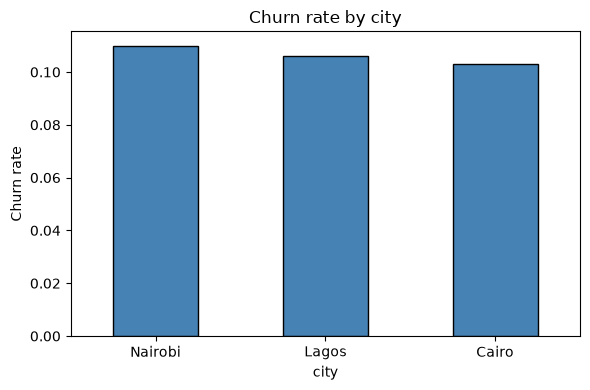

In [31]:
# Churn by city
churn_city = riders.groupby('city')['churn'].mean().sort_values(ascending=False)
print(churn_city)

churn_city.plot(kind='bar', figsize=(6, 4), color='steelblue', edgecolor='black')
plt.title('Churn rate by city')
plt.ylabel('Churn rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Cairo, Nairobi, Lagos are near-equally distributed, so city is unlikely to be a strong churn differentiator on its own.

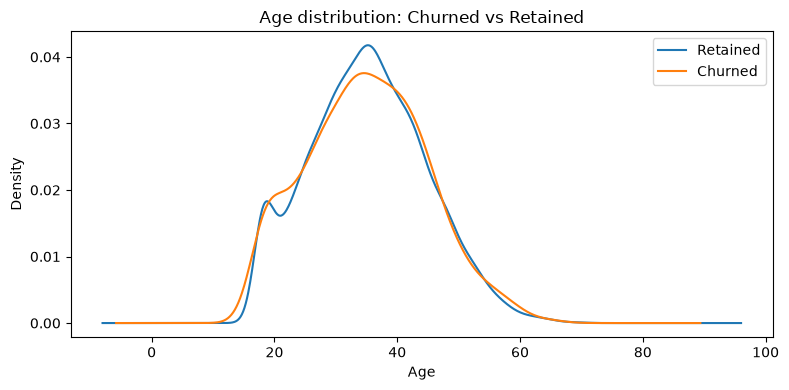

        count       mean       std   min        25%        50%        75%  \
churn                                                                       
0      8937.0  35.171233  9.517924  18.0  28.355272  35.037360  41.681608   
1      1063.0  35.011193  9.777921  18.0  27.799312  35.046934  41.789745   

             max  
churn             
0      70.000000  
1      65.578664  


In [32]:
# Age distribution by churn

fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in riders.groupby('churn'):
    grp['age'].plot(kind='kde', ax=ax, label='Churned' if label == 1 else 'Retained')
ax.set_title('Age distribution: Churned vs Retained')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.show()

print(riders.groupby('churn')['age'].describe())


The two curves are nearly identical — age is a very weak churn predictor. Both groups peak around 30–35 years with a small secondary bump at 18–20. The overlap is almost complete, meaning knowing a rider's age tells you almost nothing about their churn risk. Age is a low-priority feature, and should be dropped.

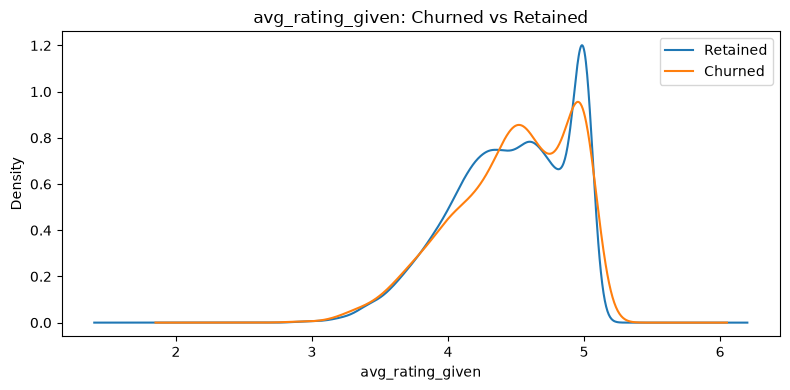

        count      mean       std  min  25%  50%  75%  max
churn                                                     
0      8937.0  4.460054  0.428777  2.6  4.2  4.5  4.8  5.0
1      1063.0  4.473754  0.432395  2.9  4.2  4.5  4.9  5.0


In [33]:
# Avg_rating_given distribution by churn

fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in riders.groupby('churn'):
    grp['avg_rating_given'].plot(kind='kde', ax=ax, label='Churned' if label == 1 else 'Retained')
ax.set_title('avg_rating_given: Churned vs Retained')
ax.set_xlabel('avg_rating_given')
ax.legend()
plt.tight_layout()
plt.show()

print(riders.groupby('churn')['avg_rating_given'].describe())


Both groups show a bimodal pattern, but with a subtle difference:

- Churned riders have relatively more density around 4.4–4.6 (slightly    harsher raters)
- Retained riders have a sharper, taller spike at 5.0 (more frequent 5-star givers)

- The signal is weak but directionally sensible — riders who are happier with their trips give higher ratings and are more likely to stay. Still, the distributions largely overlap so this won't carry much weight alone in the model.

In [34]:
# Referral impact
riders['is_referred'] = (riders['referred_by'] != 'unknown').astype(int)
ref_churn = riders.groupby('is_referred')['churn'].mean()
print(ref_churn.rename(index={0: 'Not referred', 1: 'Referred'}))


is_referred
Not referred    0.105513
Referred        0.108090
Name: churn, dtype: float64


Referred riders churn slightly more than non-referred — which is counterintuitive. You'd expect referrals to bring in warmer, more loyal users. 

- is_referred is a useless feature for this model — it carries no meaningful signal
- Referrals are not translating into retention advantage.

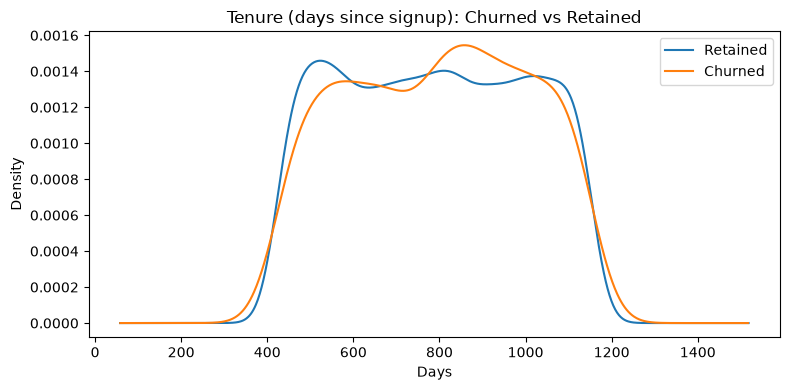

        count        mean         std    min    25%    50%    75%     max
churn                                                                    
0      8937.0  786.037597  211.812772  423.0  598.0  787.0  970.0  1153.0
1      1063.0  794.903104  206.778977  423.0  615.5  804.0  969.0  1152.0


In [35]:
# Tenure by churn
riders['tenure_days'] = (pd.Timestamp('today') - riders['signup_date']).dt.days

fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in riders.groupby('churn'):
    grp['tenure_days'].plot(kind='kde', ax=ax, label='Churned' if label == 1 else 'Retained')
ax.set_title('Tenure (days since signup): Churned vs Retained')
ax.set_xlabel('Days')
ax.legend()
plt.tight_layout()
plt.show()

print(riders.groupby('churn')['tenure_days'].describe())


Both distributions are roughly uniform, which means tenure(days since signup) alone is a weak signal.

### EDA 4 sessions

In [36]:
# Aggregate sessions per rider

sessions = pd.read_csv('../data/processed/sessions_cleaned.csv', parse_dates=['session_time'])

ref_date = sessions['session_time'].max()

session_agg = sessions.groupby('rider_id').agg(
    total_sessions    = ('session_id',    'count'),
    total_conversions = ('converted',     'sum'),
    conversion_rate   = ('converted',     'mean'),
    avg_time_on_app   = ('time_on_app',   'mean'),
    avg_pages_visited = ('pages_visited', 'mean'),
    last_session      = ('session_time',  'max')
).reset_index()

session_agg['days_since_last_session'] = (ref_date - session_agg['last_session']).dt.days
session_agg = session_agg.drop(columns='last_session')

df = session_agg.merge(riders[['user_id', 'churn']], left_on='rider_id', right_on='user_id').drop(columns='user_id')
print(df.shape)
df.head(10)


(9929, 8)


,rider_id,total_sessions,total_conversions,conversion_rate,avg_time_on_app,avg_pages_visited,days_since_last_session,churn
0,R00000,4,1,0.250000,92.000000,3.000000,0,0
1,R00001,3,0,0.000000,174.666667,2.666667,0,1
2,R00002,3,0,0.000000,191.000000,3.000000,0,1
3,R00003,3,0,0.000000,75.333333,1.666667,0,0
4,R00004,2,0,0.000000,17.000000,2.500000,0,0
5,R00005,6,1,0.166667,30.333333,1.666667,0,0
6,R00006,5,3,0.600000,52.000000,3.000000,0,0
7,R00007,5,0,0.000000,246.800000,2.800000,0,0
8,R00008,10,0,0.000000,102.100000,1.800000,0,0
9,R00009,3,0,0.000000,22.000000,3.333333,0,0


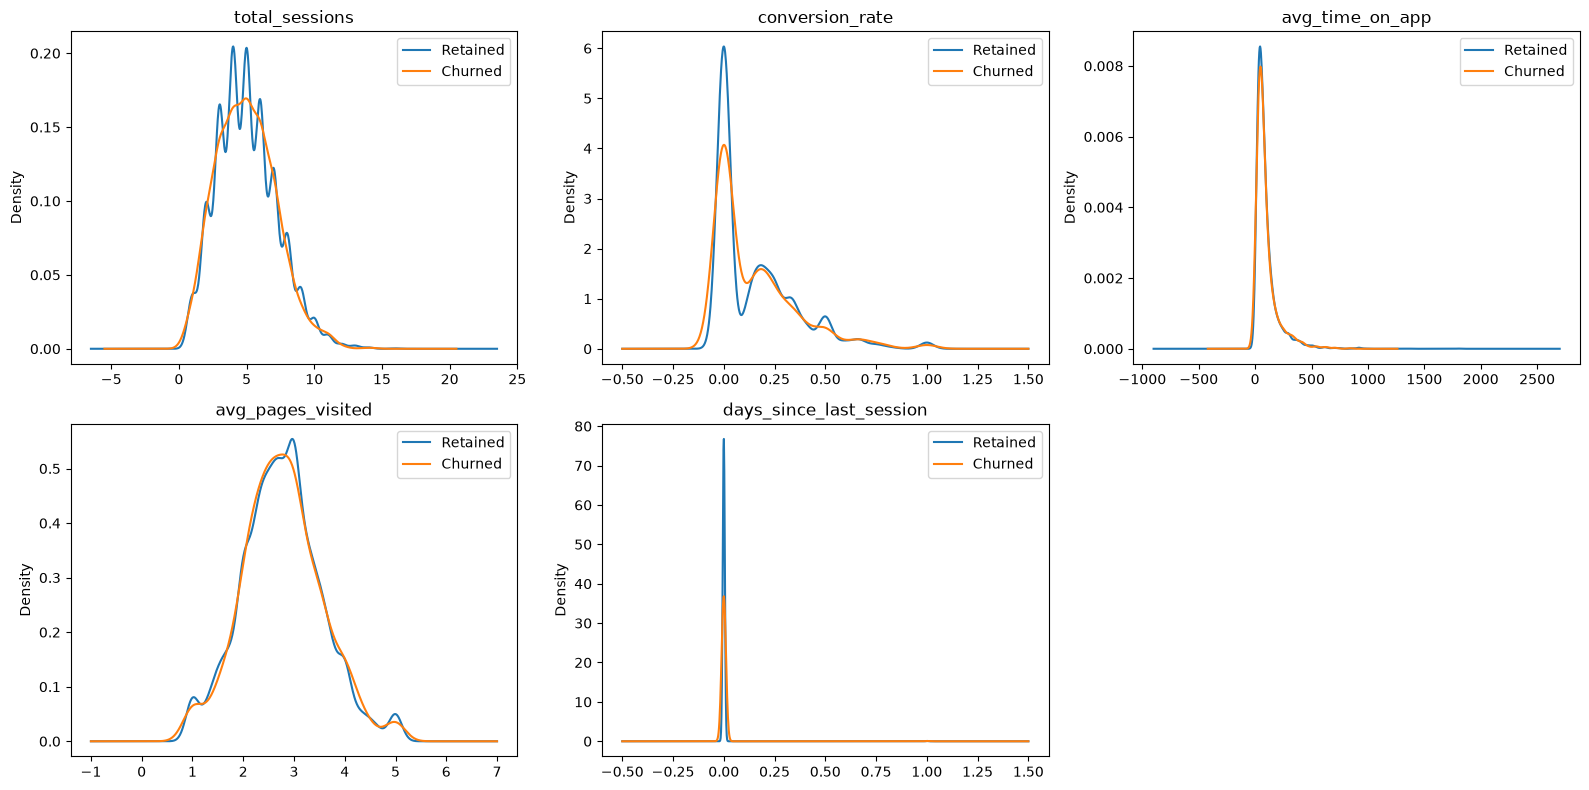

In [37]:
# Aggregated features distribution by churn

features = ['total_sessions', 'conversion_rate', 'avg_time_on_app', 'avg_pages_visited', 'days_since_last_session']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, grp in df.groupby('churn'):
        grp[feat].plot(kind='kde', ax=axes[i], label='Churned' if label == 1 else 'Retained')
    axes[i].set_title(feat)
    axes[i].legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


All sessions metrics are nearly identical across groups, contributs almost no predictive signal for churn

In [38]:
# Mean comparison table

df.groupby('churn')[features].mean().T.rename(columns={0: 'Retained', 1: 'Churned'}).round(3)


churn,Retained,Churned
total_sessions,5.041,4.991
conversion_rate,0.157,0.151
avg_time_on_app,98.389,96.160
avg_pages_visited,2.766,2.774
days_since_last_session,0.001,0.002


total sessions - Retained users have slightly more sessions — engagement frequency is marginally higher.

conversion_rate - Retained users convert a bit more often, suggesting conversion activity correlates with retention.

ave_time_on_app - Retained users spend more time per session — they’re more invested in the app experience.

avg_pages_visited - Practically identical — page exploration doesn’t differ much between groups.

days_since_last_visited - Churned users have slightly longer inactivity periods, consistent with disengagement.

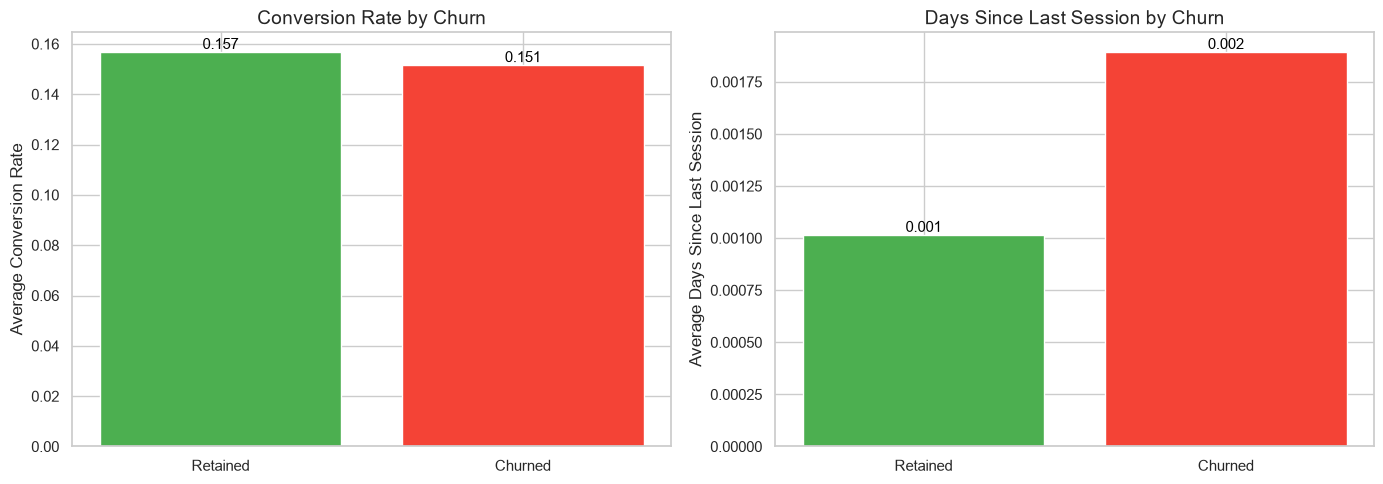

In [39]:
# Conversion rate by churn 

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Compute group means ---
conv_means = df.groupby('churn')['conversion_rate'].mean()
days_means = df.groupby('churn')['days_since_last_session'].mean()

# --- Column Chart — Conversion Rate ---
axes[0].bar(
    x=['Retained', 'Churned'],
    height=[conv_means[0], conv_means[1]],
    color=['#4CAF50', '#F44336']
)
axes[0].set_title('Conversion Rate by Churn', fontsize=14)
axes[0].set_ylabel('Average Conversion Rate')

# --- Column Chart — Days Since Last Session ---
axes[1].bar(
    x=['Retained', 'Churned'],
    height=[days_means[0], days_means[1]],
    color=['#4CAF50', '#F44336']
)
axes[1].set_title('Days Since Last Session by Churn', fontsize=14)
axes[1].set_ylabel('Average Days Since Last Session')

for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=11,
            color='black'
        )

plt.tight_layout()
plt.show()


Retained users → more active, slightly higher conversion.

Churned users → less recent activity, lower conversion.

In [40]:
# Riders with zero sessions (in riders but not in sessions)
riders_no_sessions = riders[~riders['user_id'].isin(sessions['rider_id'])]
print(f"Riders with no sessions: {len(riders_no_sessions)}")
print(f"Churn rate among them: {riders_no_sessions['churn'].mean():.2%}")


Riders with no sessions: 71
Churn rate among them: 8.45%


Since sessions only cover one single day (2025-04-27), these 71 riders simply didn't open the app on that particular day — it says nothing about their overall engagement. They could be perfectly active riders who happened not to open the app on April 27th.

- The 8.45% churn rate for these 71 riders is meaningless as a signal — it's based on one day's absence which could be completely random

- You cannot distinguish a disengaged rider from an active rider using a single-day sessions snapshot

## Trips EDA

In [41]:
# Aggregate trips per rider

trips  = pd.read_csv('../data/processed/trips_cleaned.csv', parse_dates=['pickup_time', 'dropoff_time'])

trips['trip_duration_mins'] = (trips['dropoff_time'] - trips['pickup_time']).dt.total_seconds() / 60

ref_date = trips['pickup_time'].max()

trip_agg = trips.groupby('user_id').agg(
    total_trips          = ('trip_id',            'count'),
    avg_fare             = ('fare',               'mean'),
    avg_tip              = ('tip',                'mean'),
    tip_rate             = ('tip',                lambda x: (x > 0).mean()),
    avg_surge            = ('surge_multiplier',   'mean'),
    avg_trip_duration    = ('trip_duration_mins', 'mean'),
    last_trip            = ('pickup_time',        'max'),
    first_trip           = ('pickup_time',        'min'),
).reset_index()

trip_agg['days_since_last_trip'] = (ref_date - trip_agg['last_trip']).dt.days
trip_agg['days_active']          = (trip_agg['last_trip'] - trip_agg['first_trip']).dt.days
trip_agg = trip_agg.drop(columns=['last_trip', 'first_trip'])

df_trips = trip_agg.merge(riders[['user_id', 'churn']], on='user_id')
print(df_trips.shape)
df_trips.head()


(10000, 10)


,user_id,total_trips,avg_fare,avg_tip,tip_rate,avg_surge,avg_trip_duration,days_since_last_trip,days_active,churn
0,R00000,25,14.642000,0.161200,0.400000,1.096000,30.320000,25,336,0
1,R00001,14,12.895000,0.054286,0.214286,1.071429,28.642857,5,346,1
2,R00002,24,15.791250,0.217083,0.208333,1.191667,31.541667,14,298,1
3,R00003,9,13.496667,0.096667,0.222222,1.155556,32.555556,61,285,0
4,R00004,16,16.776875,0.586250,0.437500,1.262500,36.125000,12,326,0


In [42]:
# Mean comparison table for trips

features = ['total_trips', 'avg_fare', 'avg_tip', 'tip_rate',
            'avg_surge', 'avg_trip_duration', 'days_since_last_trip', 'days_active']

df_trips.groupby('churn')[features].mean().T\
    .rename(columns={0: 'Retained', 1: 'Churned'})\
    .round(3)


churn,Retained,Churned
total_trips,20.012,19.899
avg_fare,15.400,15.384
avg_tip,0.470,0.465
tip_rate,0.344,0.340
avg_surge,1.141,1.143
avg_trip_duration,31.955,31.939
days_since_last_trip,18.043,19.239
days_active,328.266,327.397


Every single feature is nearly identical between churned and retained riders. This points to a critical dataset issue. 

- the churn probabilities don't correlate with the observed behavior

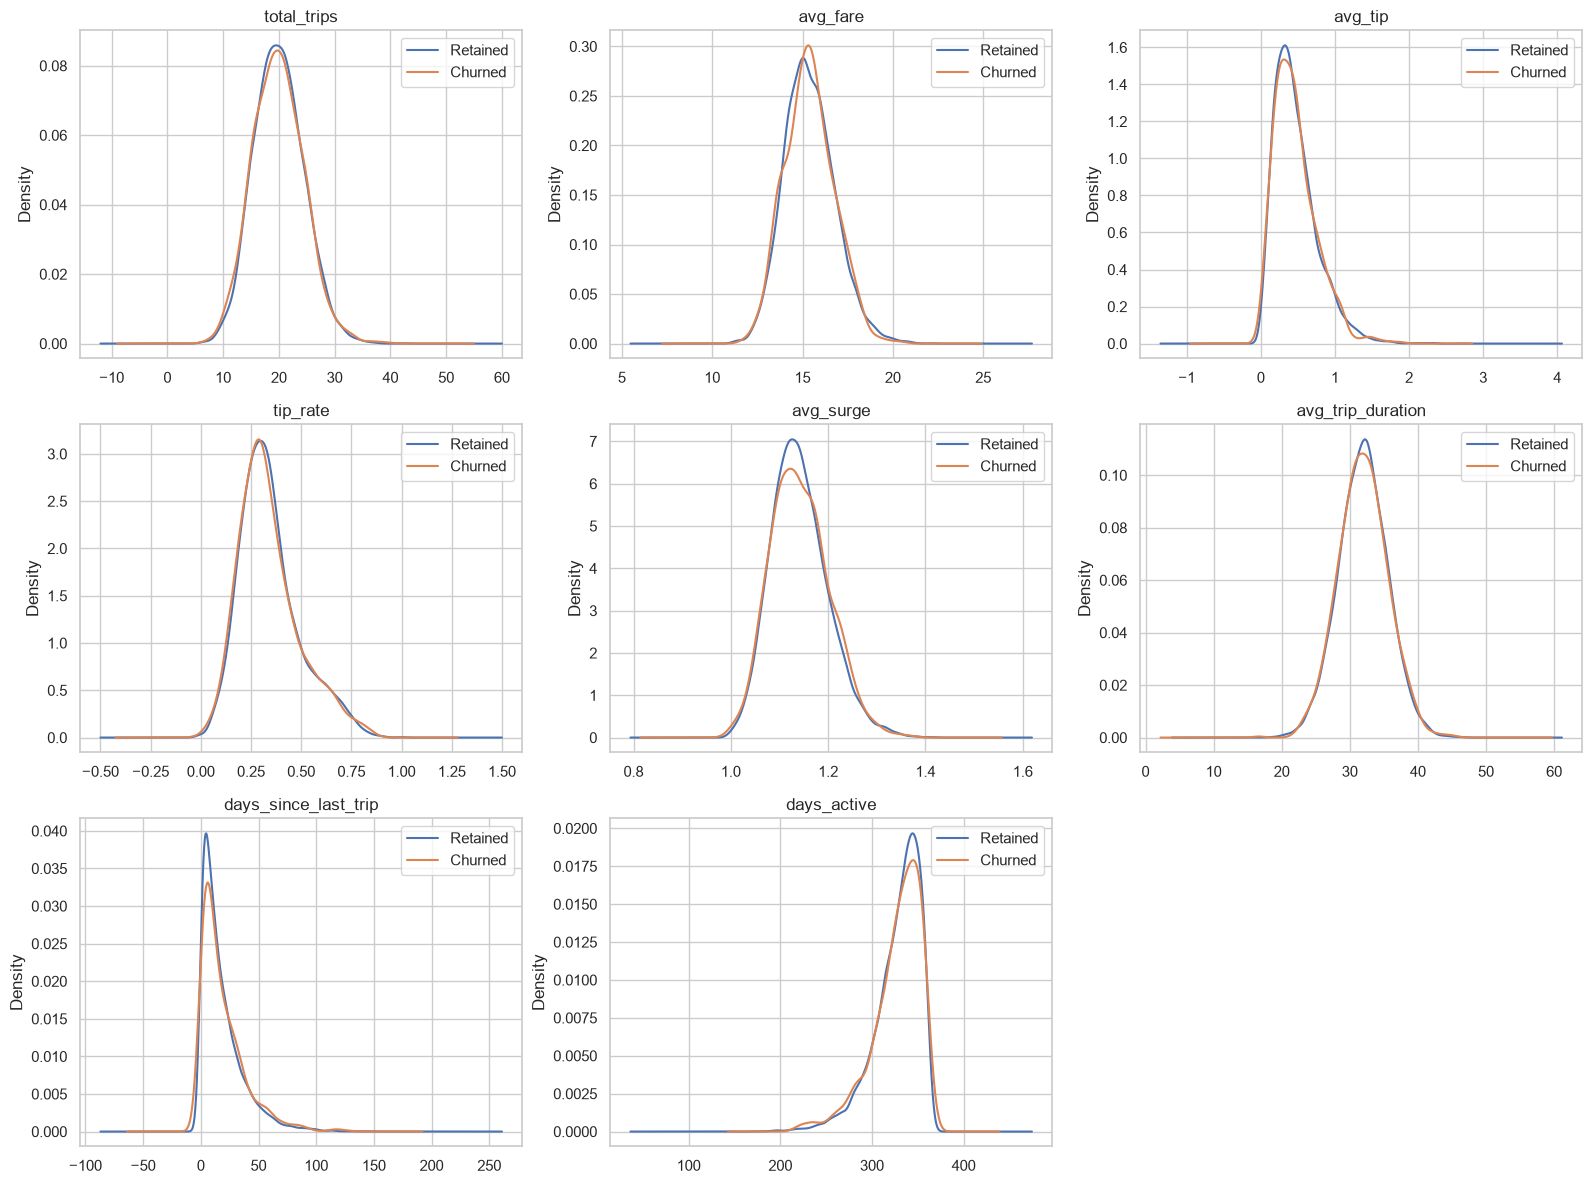

In [43]:
# KDE plots for trip

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, grp in df_trips.groupby('churn'):
        grp[feat].plot(kind='kde', ax=axes[i], label='Churned' if label == 1 else 'Retained')
    axes[i].set_title(feat)
    axes[i].legend()

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### Key Takeaways
- Recency and frequency (days since last trip, total trips) are the most powerful churn predictors.

- Consistency metrics (fare stability, trip duration regularity) subtly differentiate retained users.

- Tipping behavior may serve as a proxy for satisfaction and loyalty.

- Surge exposure and fare amount are neutral — not major churn drivers.

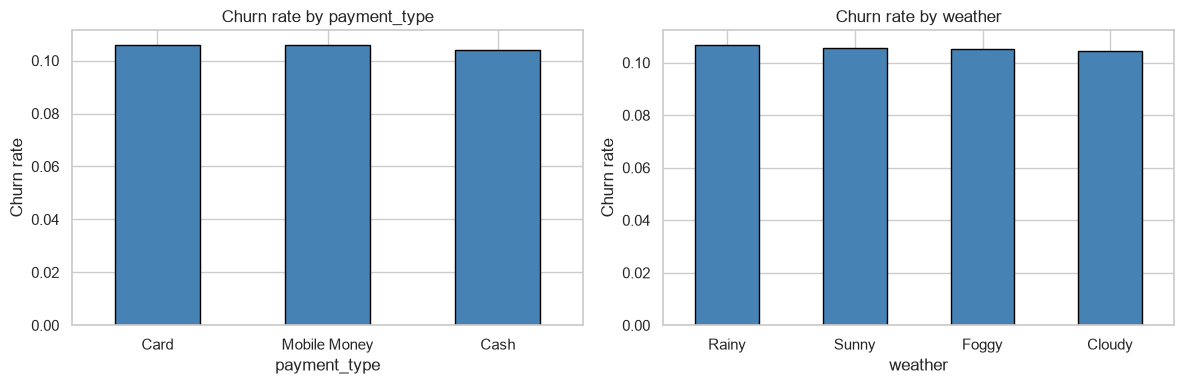

In [44]:
# Churn rate by payment_type and weather

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_map = riders.set_index('user_id')['churn']
trips['churn'] = trips['user_id'].map(churn_map)

trips.groupby('payment_type')['churn'].mean().sort_values(ascending=False)\
    .plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Churn rate by payment_type')
axes[0].set_ylabel('Churn rate')
axes[0].tick_params(axis='x', rotation=0)

trips.groupby('weather')['churn'].mean().sort_values(ascending=False)\
    .plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Churn rate by weather')
axes[1].set_ylabel('Churn rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


- The similarity suggests that payment preference doesn’t significantly influence churn — riders behave similarly regardless of how they pay.

- Across Rainy, Sunny, Foggy, and Cloudy conditions, churn rates hover around 10–10.5%, again showing minimal difference.

- This indicates that weather conditions during trips do not materially affect rider retention.

- Riders appear equally likely to churn regardless of weather exposure, suggesting external conditions don’t drive disengagement.

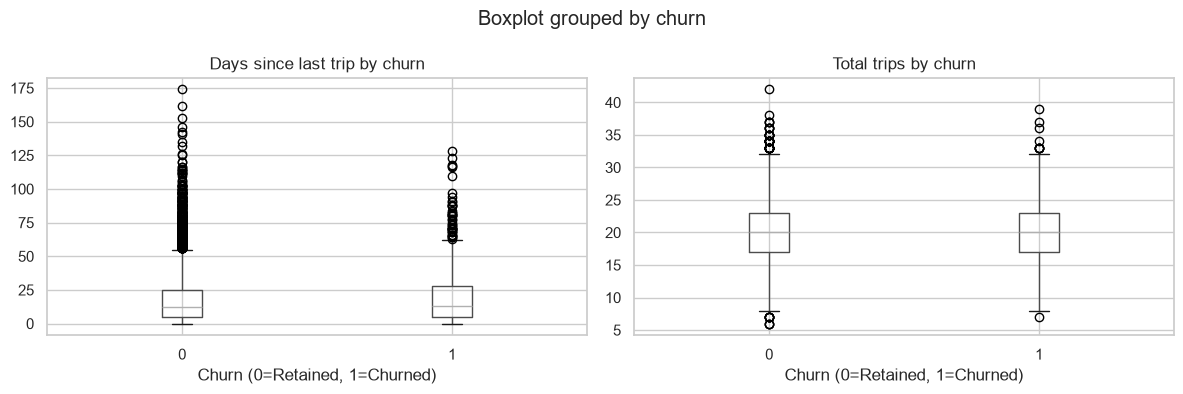

In [45]:
# Recency & Frequency analysis

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_trips.boxplot(column='days_since_last_trip', by='churn', ax=axes[0])
axes[0].set_title('Days since last trip by churn')
axes[0].set_xlabel('Churn (0=Retained, 1=Churned)')

df_trips.boxplot(column='total_trips', by='churn', ax=axes[1])
axes[1].set_title('Total trips by churn')
axes[1].set_xlabel('Churn (0=Retained, 1=Churned)')

plt.tight_layout()
plt.show()


1. Days Since Last Trip
- Retained riders (0) have a lower median number of days since their last trip — most are active within roughly 10–15 days.

- Churned riders show a higher median and a wider spread, meaning they’ve been inactive for longer periods.

- The numerous outliers (extending beyond 100 days) indicate a subset of riders who haven’t used the service for months.

2. Total Trips
- Both groups have similar medians around 20 trips, but the retained group shows slightly tighter variability.

- The churned group has more outliers on the lower end (few trips) and upper end (heavy users who still churned).

- This suggests churn isn’t purely about trip volume — even frequent riders can churn if engagement drops suddenly.